# Prysm AI — training and evaluation
This notebook reads the active validated dataset and trained artifacts. It reports class balance, training loss, accuracy, precision, recall, F1, ROC-AUC, confusion matrices, rankings, and configuration comparisons without modifying production artifacts.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
ROOT = Path.cwd() if (Path.cwd() / 'runs').exists() else Path.cwd() / 'ai-engine'
DATASET = ROOT.parent / 'data' / 'prysm-demo-v2'
RUN = ROOT / 'runs' / 'demo-v2-build'
truth = pd.read_parquet(DATASET / 'ground_truth.parquet')
pred = pd.read_parquet(RUN / 'predictions.parquet')
bundle = json.loads((RUN / 'model_bundle.json').read_text())
print(f'Cases: {len(truth):,} | people: {pd.read_parquet(DATASET / "persons.parquet").shape[0]:,} | suspicious: {truth.is_suspicious.mean():.1%}')

Cases: 10,800 | people: 32,400 | suspicious: 30.0%


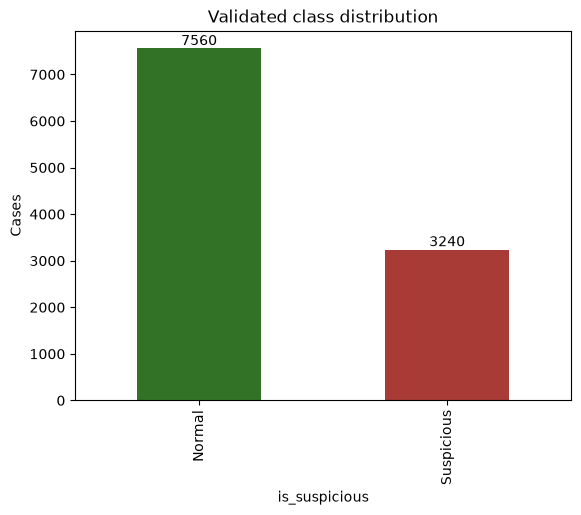

In [2]:
counts = truth.is_suspicious.map({False:'Normal', True:'Suspicious'}).value_counts()
ax = counts.plot.bar(color=['#317227','#a83b36'], title='Validated class distribution')
ax.set_ylabel('Cases'); ax.bar_label(ax.containers[0], fmt='%.0f'); plt.show()

,accuracy,precision,recall,f1,roc_auc
split,,,,,
train,1.000,1.000,1.000,1.000,1.000
validation,1.000,1.000,1.000,1.000,1.000
test,1.000,1.000,1.000,1.000,1.000


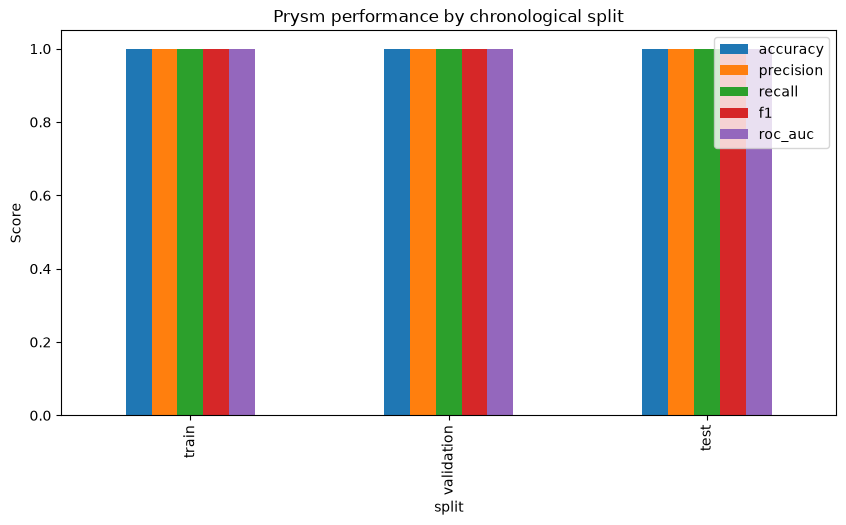

In [3]:
rows=[]
for split, frame in pred.groupby('split'):
    y=frame.target.astype(bool); score=frame.overall_strength; guess=score.ge(bundle['config']['fusion']['moderate'])
    rows.append({'split':split,'accuracy':accuracy_score(y,guess),'precision':precision_score(y,guess,zero_division=0),'recall':recall_score(y,guess,zero_division=0),'f1':f1_score(y,guess,zero_division=0),'roc_auc':roc_auc_score(y,score)})
metrics=pd.DataFrame(rows).set_index('split').loc[['train','validation','test']]
display(metrics.style.format('{:.3f}'))
metrics.plot.bar(figsize=(10,5),ylim=(0,1.05),title='Prysm performance by chronological split'); plt.ylabel('Score'); plt.show()

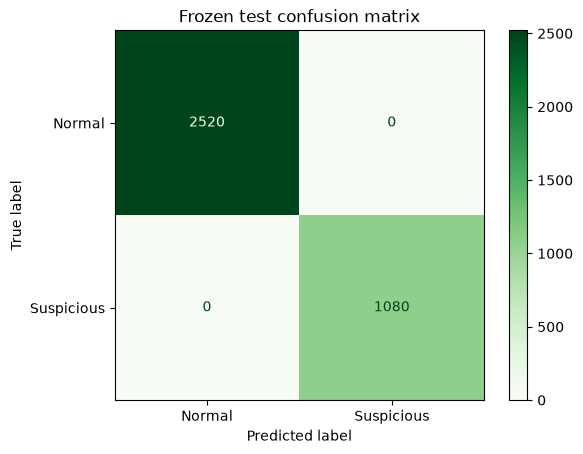

,entity_key,scenario,target,overall_strength
9208,Person:P84080,theft,True,0.714936
8078,Person:P72780,theft,True,0.714574
10393,Person:P95930,theft,True,0.714385
8593,Person:P77930,theft,True,0.714091
9307,Person:P85070,theft,True,0.713824
9456,Person:P86560,theft,True,0.713685
9775,Person:P89750,theft,True,0.713672
8099,Person:P72990,theft,True,0.713628
8105,Person:P73050,theft,True,0.713578
7951,Person:P107510,theft,True,0.713511


In [4]:
test=pred[pred.split.eq('test')]; threshold=bundle['config']['fusion']['moderate']
ConfusionMatrixDisplay.from_predictions(test.target, test.overall_strength.ge(threshold),display_labels=['Normal','Suspicious'],cmap='Greens')
plt.title('Frozen test confusion matrix'); plt.show()
display(test.nlargest(10,'overall_strength')[['entity_key','scenario','target','overall_strength']])

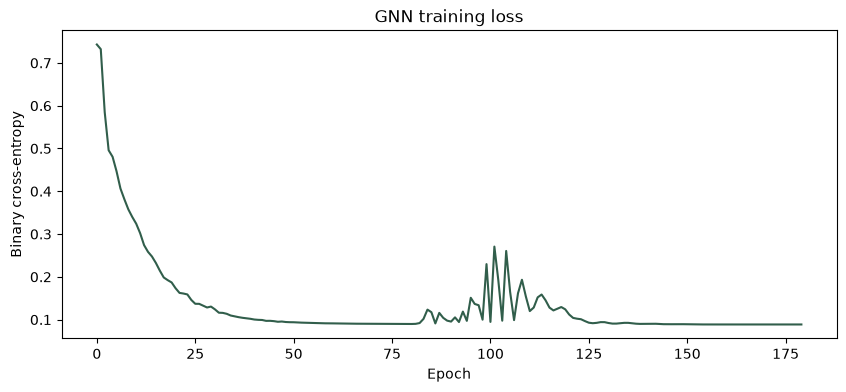

{'first_loss': 0.74304666634804, 'final_loss': 0.08869733330350194, 'epochs': 180}


In [5]:
losses=pd.Series(bundle['gnn']['training_loss'],name='training_loss')
losses.plot(figsize=(10,4),title='GNN training loss',color='#315e4b'); plt.xlabel('Epoch'); plt.ylabel('Binary cross-entropy'); plt.show()
print({'first_loss':float(losses.iloc[0]),'final_loss':float(losses.iloc[-1]),'epochs':len(losses)})

,accuracy,precision,recall,f1
threshold,,,,
0.250000,1.000,1.000,1.000,1.000
0.300000,1.000,1.000,1.000,1.000
0.350000,1.000,1.000,1.000,1.000
0.400000,1.000,1.000,1.000,1.000
0.450000,0.925,1.000,0.750,0.857
0.500000,0.925,1.000,0.750,0.857
0.600000,0.876,1.000,0.588,0.741
0.700000,0.738,1.000,0.125,0.222
0.750000,0.700,0.000,0.000,0.000


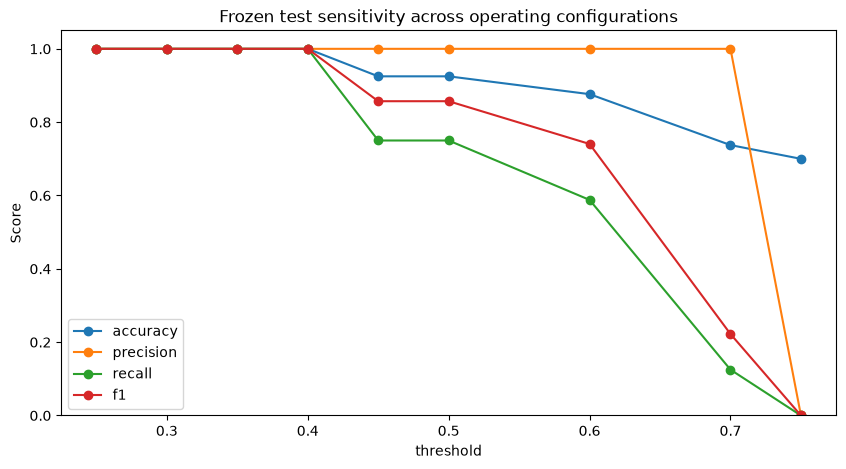

,coverage,f1
component,,
rules,1.000,0.857
network,1.000,0.400
anomaly,0.912,0.222
gnn,1.000,0.933


In [6]:
threshold_rows=[]
for configured_threshold in [0.25,0.30,0.35,0.40,0.45,0.50,0.60,0.70,0.75]:
    guess=test.overall_strength.ge(configured_threshold)
    threshold_rows.append({'threshold':configured_threshold,'accuracy':accuracy_score(test.target,guess),'precision':precision_score(test.target,guess,zero_division=0),'recall':recall_score(test.target,guess,zero_division=0),'f1':f1_score(test.target,guess,zero_division=0)})
thresholds=pd.DataFrame(threshold_rows).set_index('threshold')
display(thresholds.style.format('{:.3f}'))
thresholds.plot(figsize=(10,5),ylim=(0,1.05),marker='o',title='Frozen test sensitivity across operating configurations'); plt.ylabel('Score'); plt.show()
component_rows=[]
for component in ['rules','network','anomaly','gnn']:
    scores=test[f'{component}_score']; available=scores.notna(); configured=bundle['config'].get(component,{}).get('threshold',0.5)
    component_rows.append({'component':component,'coverage':available.mean(),'f1':f1_score(test.loc[available,'target'],scores[available].ge(configured),zero_division=0)})
display(pd.DataFrame(component_rows).set_index('component').style.format('{:.3f}'))